In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 한글 폰트 설정 (윈도우/맥/리눅스 환경별로 맞는 폰트 지정)
plt.rc('font', family='Malgun Gothic')  # 윈도우: 'Malgun Gothic'
# 마이너스(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('fill/train_preprocessed_check.csv')
test_df = pd.read_csv('fill/test_preprocessed_check.csv')
print(df.shape, test_df.shape)
Y = df['stress_score']
X = df.drop(columns=['stress_score'])

(3000, 26) (3000, 25)


In [15]:
df['bmi'] = (df['weight'] / ((df['height'] / 100.0) ** 2)).round(2)
test_df['bmi'] = (test_df['weight'] / ((test_df['height'] / 100.0) ** 2)).round(2)

In [16]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVR


from sklearn.decomposition import KernelPCA
from sklearn.preprocessing import StandardScaler


# 2. (권장) 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. 커널 PCA 적용 (예: rbf 커널, 주성분 3개)
kpca = KernelPCA(n_components=3, kernel='rbf', gamma=0.1, random_state=42)
X_kpca = kpca.fit_transform(X_scaled)

# 5. 원본 데이터와 합치기
kpca_cols = [f'kpca_{i+1}' for i in range(X_kpca.shape[1])]
df_kpca = pd.DataFrame(X_kpca, columns=kpca_cols, index=df.index)
df_augmented = pd.concat([X, df_kpca], axis=1).values


In [17]:
li = []
kf = KFold(n_splits=10, shuffle=True, random_state=42)
for train_index, val_index in kf.split(df_augmented):
    x_train, x_val = df_augmented[train_index], df_augmented[val_index]
    y_train, y_val = Y[train_index], Y[val_index]

    pipe = make_pipeline(
                StandardScaler(),
                TransformedTargetRegressor(
                    regressor=SVR(
                        C = 4.4157430376032805, 
                        gamma =  0.4474395747665764,
                        epsilon = 0.0,  # 고정값, 타깃 스케일링 기준
                        kernel="rbf",
                        shrinking=True,
                        cache_size=500,   # MB, 속도 도움

                    ),
                   transformer=QuantileTransformer(output_distribution="normal",
                                        n_quantiles=min(1000, len(Y)))
                )
            )
    pipe.fit(x_train, y_train)

    # 검증 데이터에 대한 예측
    y_pred = pipe.predict(x_val)

    # MAE 계산
    mae = mean_absolute_error(y_val, y_pred)
    li.append(mae)

    
print(f'Fold MAE: {np.mean(li):.8f}')

Fold MAE: 0.14339210


In [ ]:
.14339210

In [ ]:
0.2285

# 교차검증 기본모델 성능실험

In [31]:
from sklearn.model_selection import KFold


X = df.drop(columns=['stress_score']).values
Y = df['stress_score'].values

li = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, val_index in kf.split(X):
    x_train, x_val = X[train_index], X[val_index]
    y_train, y_val = Y[train_index], Y[val_index]

    # 선형 회귀 모델 학습
    model = xgb.XGBRegressor()
    model.fit(x_train, y_train)

    # 검증 데이터에 대한 예측
    y_pred = model.predict(x_val)

    # MAE 계산
    mae = mean_absolute_error(y_val, y_pred)
    li.append(mae)
    
print(f'Fold MAE: {np.mean(li):.4f}')

Fold MAE: 0.1911


In [13]:
import random
from sklearn.model_selection import KFold
import catboost as cb
df = pd.read_csv('open/train.csv')
df.loc[df['mean_working'].isnull(),'mean_working'] = 0
df.fillna('Unknown', inplace=True)
print(df.drop(columns=['stress_score','ID']).info())
X = df.drop(columns=['stress_score','ID']).values
Y = df['stress_score'].values


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   gender                    3000 non-null   object 
 1   age                       3000 non-null   int64  
 2   height                    3000 non-null   float64
 3   weight                    3000 non-null   float64
 4   cholesterol               3000 non-null   float64
 5   systolic_blood_pressure   3000 non-null   int64  
 6   diastolic_blood_pressure  3000 non-null   int64  
 7   glucose                   3000 non-null   float64
 8   bone_density              3000 non-null   float64
 9   activity                  3000 non-null   object 
 10  smoke_status              3000 non-null   object 
 11  medical_history           3000 non-null   object 
 12  family_medical_history    3000 non-null   object 
 13  sleep_pattern             3000 non-null   object 
 14  edu_leve

- 하이퍼파라미터튜닝

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK
import xgboost as xgb


def tune_xgb_mae_cv(X, y, max_evals=60, n_splits=5, random_state=42,early_stopping_rounds=30):
    X_arr = X.values if hasattr(X, "values") else X
    y_arr = y.values if hasattr(y, "values") else y

    def objective(params):
        # 정수 변환
        params["max_depth"] = int(params["max_depth"])
        params["n_estimators"] = int(params["n_estimators"])
        params["min_child_weight"] = int(params["min_child_weight"])

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        fold_maes = []

        for tr_idx, val_idx in kf.split(X_arr):
            X_tr, X_val = X_arr[tr_idx], X_arr[val_idx]
            y_tr, y_val = y_arr[tr_idx], y_arr[val_idx]

            model = xgb.XGBRegressor(
                random_state=random_state,
                n_jobs=-1,
                objective='reg:squarederror',
                eval_metric="mae",
                verbosity=0,
                early_stopping_rounds= early_stopping_rounds,
                **params,

            )

            model.fit(
                X_tr, 
                y_tr,
                eval_set=[(X_val, y_val)],
                verbose=False,
                
            )
            #print(f"얼리 스톱핑 적용! 최적 트리 개수: {model.best_iteration} / 원래 설정값: {params['n_estimators']}")

            pred = model.predict(X_val)
            fold_maes.append(mean_absolute_error(y_val, pred))

        mean_mae = np.mean(fold_maes)
        return {"loss": mean_mae, "status": STATUS_OK}

    # regularization candiate 정의
    reg_candidate = [1e-5, 1e-4, 1e-3, 1e-2, 0, 0.1, 1, 5, 10,20,30]
    gamma_candidate = np.r_[0.0, np.logspace(-8, -2, num=7, base=10)]
 
    # space 정의, Hyperparameter의 이름을 key 값으로 입력
    space={
        'max_depth': hp.quniform("max_depth", 8, 14, 1),
        'learning_rate': hp.quniform ('learning_rate', 0.01, 0.2, 0.01),
        'reg_alpha' : hp.choice('reg_alpha', reg_candidate),
        'reg_lambda' : hp.choice('reg_lambda', reg_candidate), # 인덱스 값이 나옴
        'subsample': hp.quniform('subsample', 0.6, 1, 0.1),
        'gamma': hp.choice('gamma', gamma_candidate), # 인덱스 값이 나옴
        'colsample_bytree' : hp.quniform('colsample_bytree', 0.5, 1, 0.1),
        'min_child_weight' : hp.quniform('min_child_weight', 1, 10, 1),
        'n_estimators': hp.quniform('n_estimators', 800, 1500, 100)
        }

    trials = Trials()
    best = fmin(
        fn=objective, 
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(random_state),
    )

    #여기에 있어야 리턴이됨
    best_params = { 
        "max_depth": int(best["max_depth"]),   
        "learning_rate": best["learning_rate"],
        "n_estimators": int(best["n_estimators"]),
        "subsample": best["subsample"],
        "colsample_bytree": best["colsample_bytree"],
        "min_child_weight": int(best["min_child_weight"]),
        "reg_alpha":  reg_candidate[best["reg_alpha"]], 
        "reg_lambda": reg_candidate[best["reg_lambda"]],
        "gamma": gamma_candidate[best["gamma"]]
    }

    best_mae = min([r["loss"] for r in trials.results])

    return {
        "best_params": best_params, 
        "best_cv_mae": best_mae,
        "trials": trials,
        "best": best
    }    




In [ ]:
# X, y는 numpy array여야 함 (예: pandas라면 .values로)
summary = tune_xgb_mae_cv(X,
                         Y,
                          max_evals=80,
                          n_splits=10,
                          random_state=42)  
print("CV MAE:", summary["best_cv_mae"])
print("Best params:", summary["best_params"])


+ 100%|██████████| 80/80 [47:02<00:00, 35.28s/trial, best loss: 0.15653826760878783] 
+ CV MAE: 0.15653826760878783
+ Best params: {'max_depth': 18, 'learning_rate': 0.05, 'n_estimators': 2000, 'subsample': 0.9, 'colsample_bytree': 0.6000000000000001, 'min_child_weight': 9, 'reg_alpha': 0.001, 'reg_lambda': 10, 'gamma': 1e-06}

# 제출

train mae 0.0007806029691495729


<Axes: >

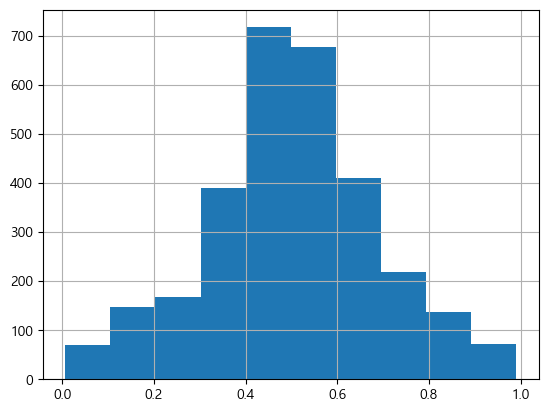

In [42]:

model = xgb.XGBRegressor(random_state=42,**summary["best_params"])
model.fit(X, Y)
train_pred = model.predict(X)
mae = mean_absolute_error(Y, train_pred)
 
print(f'train mae {mae}')

pred = model.predict(test_df)
submit = pd.read_csv('open/sample_submission.csv')
submit['stress_score'] = pred
submit.to_csv('submission_base.csv', index=False)
submit['stress_score'].hist()

In [6]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error
import xgboost as xgb

def stacking_predict(X, y, test_X, n_splits=5, random_state=42):
    # 데이터 numpy array로 변환
    X = X.values if hasattr(X, "values") else X
    y = y.values if hasattr(y, "values") else y
    test_X = test_X.values if hasattr(test_X, "values") else test_X

    # base models: XGB, Ridge, RF, KNN, SVR, NN (MLP)
    base_models = {
        'xgb': xgb.XGBRegressor(),
        'ridge': Ridge(),
        'rf': RandomForestRegressor(),
        'knn': KNeighborsRegressor(),
        'svr': SVR(),
        'nn': MLPRegressor(hidden_layer_sizes=(32, 32), max_iter=300, random_state=random_state)
    }
    scale_models = ['ridge', 'knn', 'svr', 'nn']  # scaling 필요한 모델만
    
    model_names = list(base_models.keys())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    # OOF 및 test stacking feature matrix
    oof_stack = np.zeros((len(X), len(model_names)))
    test_stack = np.zeros((len(test_X), len(model_names)))

    for m_idx, (name, model) in enumerate(base_models.items()):
        print(f"Base model: {name}")
        oof_pred = np.zeros(len(X))
        test_fold_preds = []

        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr = y[train_idx]

            # scaling 필요하면 fold별로 맞춤
            if name in scale_models:
                scaler = StandardScaler().fit(X_tr)
                X_tr_ = scaler.transform(X_tr)
                X_val_ = scaler.transform(X_val)
                test_X_ = scaler.transform(test_X)
            else:
                X_tr_, X_val_, test_X_ = X_tr, X_val, test_X

            model.fit(X_tr_, y_tr)
            oof_pred[val_idx] = model.predict(X_val_)
            test_fold_preds.append(model.predict(test_X_))
        
        oof_stack[:, m_idx] = oof_pred
        # test_fold_preds: (n_splits, len(test_X)) → 평균(앙상블)
        test_stack[:, m_idx] = np.mean(test_fold_preds, axis=0)

    # meta model: Ridge (no tuning, 필요시 교체)
    meta_model = MLPRegressor()
    meta_model.fit(oof_stack, y)
    meta_oof = meta_model.predict(oof_stack)
    meta_test = meta_model.predict(test_stack)

    print("Stacking OOF MAE:", mean_absolute_error(y, meta_oof))

    return meta_test, meta_oof, oof_stack, test_stack

In [7]:
pred ,_,_,_ = stacking_predict(X, Y, test_df)

Base model: xgb
Base model: ridge
Base model: rf
Base model: knn
Base model: svr
Base model: nn
Stacking OOF MAE: 0.18454603279617557


<Axes: >

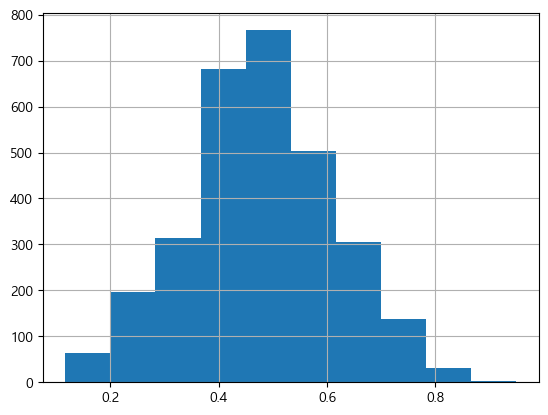

In [8]:
submit = pd.read_csv('open/sample_submission.csv')
submit['stress_score'] = pred
submit.to_csv('submission_base.csv', index=False)
submit['stress_score'].hist()

# SHAP

In [ ]:
import shap


X_scaled_df = pd.DataFrame(X, columns=X.columns, index=X.index)
explainer = shap.Explainer(model, X_scaled_df)
shap_values = explainer(X_scaled_df)
shap.summary_plot(shap_values, X_scaled_df)  

c:\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
 74%|===============     | 2226/3000 [10:50<03:46]       

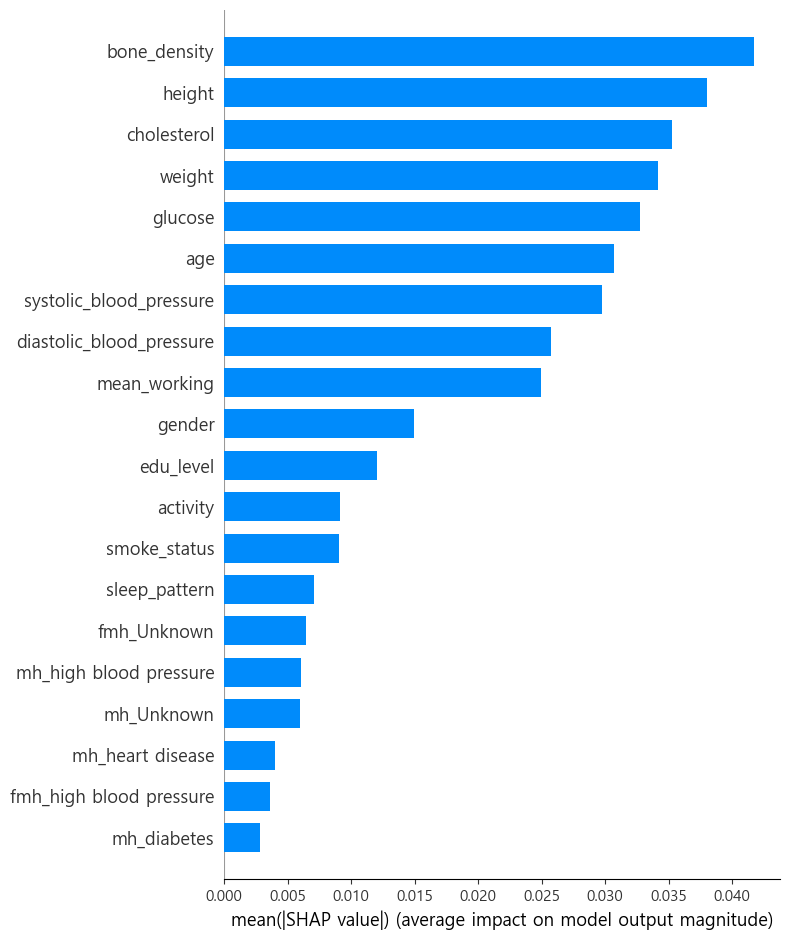

In [71]:
shap.summary_plot(shap_values, X_scaled_df,plot_type='bar') 

# 엔지니어링

In [8]:
df

,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,...,mh_diabetes,mh_heart disease,mh_high blood pressure,fmh_Unknown,fmh_diabetes,fmh_heart disease,fmh_high blood pressure,smo_0,smo_1,smo_2
0,0,72,161.49,58.47,279.84,165,100,143.35,0.87,1,...,0,0,1,0,1,0,0,0,1,0
1,1,88,179.87,77.60,257.37,178,111,146.94,0.07,1,...,0,0,0,0,1,0,0,0,1,0
2,1,47,182.47,89.93,226.66,134,95,142.61,1.18,0,...,0,0,0,1,0,0,0,0,1,0
3,1,69,185.78,68.63,206.74,158,92,137.26,0.48,2,...,0,0,1,1,0,0,0,0,1,0
4,0,81,164.63,71.53,255.92,171,116,129.37,0.34,1,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,0,87,174.43,77.14,233.31,176,111,134.71,0.20,0,...,0,0,0,1,0,0,0,1,0,0
2996,1,25,171.44,51.67,196.89,143,86,111.91,1.75,1,...,0,0,0,1,0,0,0,0,0,1
2997,0,54,162.13,55.54,210.52,164,91,136.47,0.80,0,...,0,0,0,1,0,0,0,0,0,1
2998,1,70,181.32,82.20,234.10,182,91,144.89,0.58,1,...,0,0,0,1,0,0,0,1,0,0


In [91]:
df  = pd.read_csv('fill/train.csv')
#df['is_high_chol'] = (df['cholesterol'] > 230).astype(int)

# 고혈압 여부 (수축기 > 140 or 이완기 > 90 mmHg)
# df['is_high_bp'] = ((df['systolic_blood_pressure'] > 130) | 
#                     (df['diastolic_blood_pressure'] > 80)).astype(int)

# # 고혈당(당뇨 위험) 여부 (혈당 > 126 mg/dL, 공복혈당 기준)
# df['is_high_glucose'] = (df['glucose'] > 126).astype(int)

mw = df['mean_working']
weekly_hours = mw * 7

# 구간 설정 (미취업/파트/정규/초과)
conditions = [
    (mw == 0),                       # 무직 (혹은 결측)
    (weekly_hours < 28) & (mw != 0), # 파트타임
    (weekly_hours < 41) & (weekly_hours >= 28),
    (weekly_hours >= 41)
]
choices = ['none', 'part_time', 'full_time', 'overwork']
df['working_category'] = np.select(conditions, choices)

df['working_category'] = df['working_category'].map({
    'none': 0,
    'part_time': 1,
    'full_time': 2,
    'overwork': 3})



Y = df['stress_score'].values
X = df.drop(columns=['stress_score']).values

from sklearn.model_selection import KFold


li = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_index, val_index in kf.split(X): 
    x_train, x_val = X[train_index], X[val_index]
    y_train, y_val = Y[train_index], Y[val_index]

    # 선형 회귀 모델 학습
    model = xgb.XGBRegressor()
    model.fit(x_train, y_train)

    # 검증 데이터에 대한 예측
    y_pred = model.predict(x_val)

    # MAE 계산
    mae = mean_absolute_error(y_val, y_pred)
    li.append(mae)
    
print(f'Fold MAE: {np.mean(li):.4f}')

Fold MAE: 0.1911


<Axes: >

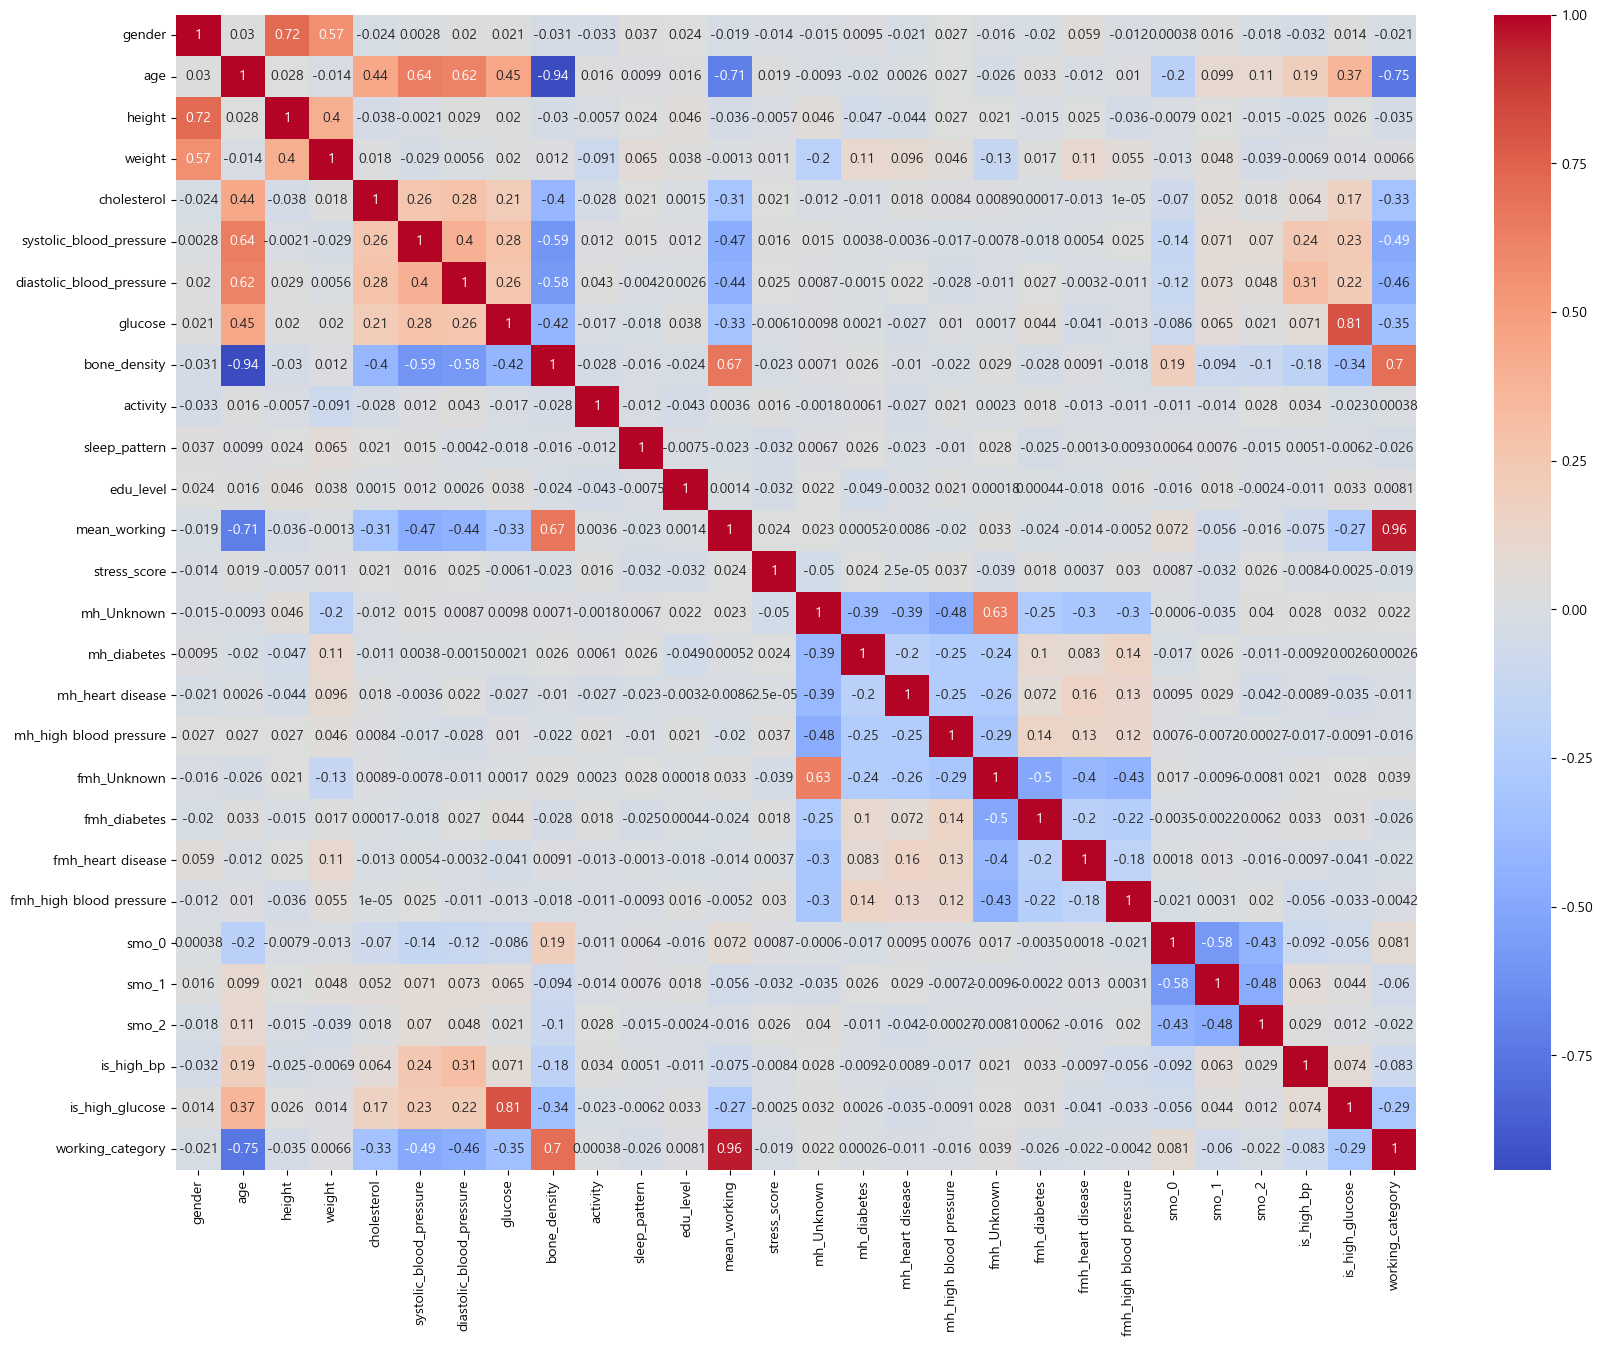

In [89]:

plt.figure(figsize=(20, 15))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [84]:
# X, y는 numpy array여야 함 (예: pandas라면 .values로)
summary = tune_xgb_mae_cv(X,
                         Y,
                          max_evals=80,
                          n_splits=5)
print("CV MAE:", summary["best_cv_mae"])
print("Best params:", summary["best_params"])

  0%|          | 0/80 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 80/80 [06:23<00:00,  4.79s/trial, best loss: 0.17057855690304188]
CV MAE: 0.17057855690304188
Best params: {'max_depth': 12, 'learning_rate': 0.15, 'n_estimators': 1100, 'subsample': 1.0, 'colsample_bytree': 0.7000000000000001, 'min_child_weight': 3, 'reg_alpha': 1, 'reg_lambda': 7}


(3000, 26)
train mae 0.0009478249652706045
(3000, 26)


<Axes: >

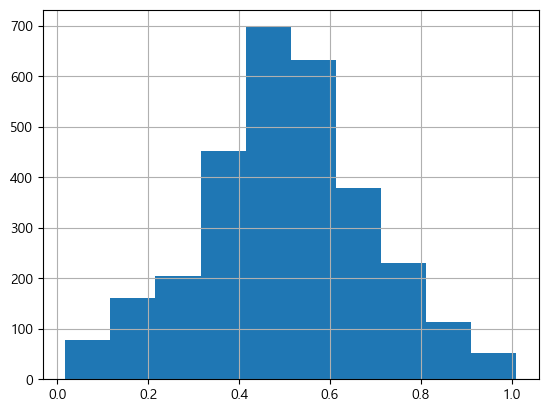

In [86]:
xgb_reg_candidate = [1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1, 5, 10,20,30]
xgb_params =  {'max_depth': 12, 'learning_rate': 0.15, 'n_estimators': 1100, 'subsample': 1.0, 'colsample_bytree': 0.7000000000000001, 'min_child_weight': 3, 'reg_alpha': xgb_reg_candidate[1], 'reg_lambda': xgb_reg_candidate[7]}

model = xgb.XGBRegressor(random_state=42,**xgb_params)
print(X.shape)
model.fit(X, Y)
train_pred = model.predict(X)
mae = mean_absolute_error(Y, train_pred)

print(f'train mae {mae}')

test_df = pd.read_csv('fill/test.csv')
test_df['is_high_bp'] = ((test_df['systolic_blood_pressure'] > 130) | 
                         (test_df['diastolic_blood_pressure'] > 80)).astype(int)
test_df['is_high_glucose'] = (test_df['glucose'] > 126).astype(int)
print(test_df.shape)
pred = model.predict(test_df)
submit = pd.read_csv('open/sample_submission.csv')
submit['stress_score'] = pred
submit.to_csv('submission_base.csv', index=False)
submit['stress_score'].hist()